## Block 1: Imports and Setup

This block loads all required libraries and defines file paths for the three datasets used in this tutorial.

`aif360` is the primary fairness auditing library. It provides tools for measuring bias in datasets and model predictions, and for applying mitigation techniques. If it is not installed, run `pip install aif360` before proceeding.

File paths are defined at the top so you only need to update them in one place. The shared color palette ensures consistent visual encoding across all three datasets in the comparison plots.

Warnings can be suppressed because AIF360 produces verbose deprecation notices that would interrupt the flow of a live tutorial. This does not affect any results.

In [1]:
# ============================================================
# Block 1: Imports and Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Dataset Paths -- update if your file locations differ
# ============================================================

OASIS_PATH = 'oasis_longitudinal_demographics.xlsx'
ABIDE_PATH = 'Phenotypic_V1_0b.csv'
NIGERIAN_PATH = 'nigerian_brain_participants.tsv'

# ============================================================
# Shared color palette across all three datasets
# ============================================================

COLORS = {
    'OASIS2':   '#4C9BE8',
    'ABIDE':    '#E8834C',
    'Nigerian': '#4CAF50'
}

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


## Block 2: Load and Standardize Datasets

Each dataset is loaded and renamed to a shared schema with consistent column names across all three. Only first visits are kept for OASIS-2 to avoid data leakage across train and test sets.

Binary encodings are defined as follows:

**OASIS-2**
- Label: Nondemented = 0, Demented or Converted = 1
- Sex: Female = 1, Male = 0
- SES: scores 3 and above = 1 (lower privilege), scores below 3 = 0

**ABIDE**
- Label: ASD = 1, Control = 0
- Sex: Female = 1, Male = 0
- Site: Europe = 1 (unprivileged), North America = 0 (privileged)

**Nigerian Brain**
- Label: Control = 0, all clinical groups = 1
- Sex: Female = 1, Male = 0
- SES: lower = 1, middle or upper = 0

> **Note on ABIDE missingness:** 35 subjects were dropped due to missing FIQ values. All 35 come from a single site, LEUVEN_2 in Belgium. This means LEUVEN_2 is entirely absent from the analysis, and the European group in the fairness audit represents only three sites rather than four. This is not a random omission. It changes who the European group represents and should be kept in mind when interpreting site-based fairness metrics.


### Data Load
OASIS-2 (150 x 19):
- 150 first visits as expected after filtering, 19 columns including the imaging features.

ABIDE (1077 x 78):
- 1,077 subjects after dropping rows with missing IQ. Started at 1,112 so 35 subjects were dropped due to missing FIQ values. 78 columns is the full phenotypic file.

Nigerian (88 x 11):
- all 88 subjects retained, no missing values in the columns we need. 11 columns after renaming.

In [6]:
# ============================================================
# Block 2: Load and Standardize Datasets
# ============================================================

# --- OASIS-2 ---
oasis_raw = pd.read_excel(OASIS_PATH)
oasis = oasis_raw[oasis_raw['Visit'] == 1].copy()
oasis = oasis.rename(columns={
    'Subject ID': 'participant_id',
    'M/F':        'sex',
    'Age':        'age',
    'Educ':       'education',
    'SES':        'ses',
    'MMSE':       'mmse',
    'CDR':        'cdr',
    'nWBV':       'nWBV',
    'eTIV':       'eTIV'
})
oasis['label']   = (oasis['Group'] != 'Nondemented').astype(int)
oasis['sex_bin'] = (oasis['sex'] == 'F').astype(int)
oasis['ses_bin'] = (oasis['ses'] >= 3).astype(int)
oasis['dataset'] = 'OASIS2'
oasis = oasis.dropna(subset=['sex_bin', 'ses_bin', 'nWBV', 'eTIV', 'mmse'])

# --- ABIDE ---
abide_raw = pd.read_csv(ABIDE_PATH)
abide = abide_raw.copy()
abide = abide.rename(columns={
    'SUB_ID':        'participant_id',
    'SEX':           'sex',
    'AGE_AT_SCAN':   'age',
    'FIQ':           'iq',
    'DX_GROUP':      'dx'
})

# North America = 0 (privileged, larger representation)
# Europe = 1 (unprivileged, smaller representation)
north_america = ['NYU','UM_1','USM','UCLA_1','PITT','YALE','KKI',
                 'STANFORD','CALTECH','OLIN','SDSU','OHSU','CMU',
                 'UCLA_2','SBL','UM_2']
europe        = ['MAX_MUN','TRINITY','LEUVEN_1','LEUVEN_2']

abide['site_bin'] = abide['SITE_ID'].apply(
    lambda x: 1 if x in europe else 0
)
abide['label']   = (abide['dx'] == 1).astype(int)  # 1 = ASD
abide['sex_bin'] = (abide['sex'] == 2).astype(int)  # 2 = Female
abide['dataset'] = 'ABIDE'
abide = abide.dropna(subset=['sex_bin', 'site_bin', 'iq'])

# --- Nigerian Clinical ---
nigerian_raw = pd.read_csv(NIGERIAN_PATH, sep='\t')
nigerian = nigerian_raw.copy()
nigerian = nigerian.rename(columns={
    'participant_id': 'participant_id',
    'age':            'age',
    'sex':            'sex',
    'SES':            'ses',
    'Education':      'education',
    'GeopoliticalRegion': 'region',
    'ClincalGroup':  'dx'
})
nigerian['label']   = (nigerian['dx'] != 'Control').astype(int)
nigerian['sex_bin'] = (nigerian['sex'] == 'F').astype(int)
nigerian['ses_bin'] = (nigerian['ses'] == 'lower').astype(int)
nigerian['dataset'] = 'Nigerian'
nigerian = nigerian.dropna(subset=['sex_bin', 'ses_bin'])

print("OASIS-2:  ", oasis.shape)
print("ABIDE:    ", abide.shape)
print("Nigerian: ", nigerian.shape)

OASIS-2:   (150, 19)
ABIDE:     (1077, 78)
Nigerian:  (88, 11)


## Block 3: Demographic Exploration

Before running any models, it is important to understand who is actually in each dataset and what structural imbalances exist. The plots above show age, sex, and a third variable (SES or site region) broken down by diagnosis group for each dataset.

### What to look for

**OASIS-2**
The Demented and Converted groups are older on average than the Nondemented group. This age confound means a classifier trained on brain volume features may be learning age rather than diagnosis. The dataset is also female-dominated, particularly in the Nondemented group.

**ABIDE**
The sex imbalance is severe. Male participants outnumber female participants by roughly 6 to 1 across both diagnosis groups. This reflects a well-documented pattern in autism research where females are historically underdiagnosed and underrepresented in clinical datasets. The site region plot shows that North American sites contribute the overwhelming majority of subjects. European sites account for roughly 135 subjects across three sites after LEUVEN_2 was excluded due to missing FIQ values.

**Nigerian Clinical**
The Control group skews younger than the Dementia and Parkinson groups, which is expected clinically. SES is unevenly distributed across diagnosis groups, with lower SES participants more concentrated in the clinical groups. This pattern is worth examining carefully in the fairness audit.

### Ethical Checkpoint 1: What features imbalances are seen?

**1. Age confounds**
Age and diagnosis are entangled in all three datasets. Any classifier may learn to detect age rather than the clinical condition of interest.

**2. Sex imbalance**
All three datasets have more male than female participants. The imbalance is most extreme in ABIDE. This is not a data quality problem. It reflects who gets diagnosed, who gets referred for research, and who gets included.

**3. Geographic concentration**
ABIDE draws the majority of its subjects from North American institutions. The Nigerian Clinical dataset is the only one collected outside of Europe and North America. No dataset here includes participants from Asia, South America, or most of Africa.

**4. Small subgroups**
Once you split by diagnosis and then by a protected attribute, some subgroups become very small. Fairness metrics computed on small subgroups carry wide uncertainty even when the numbers look precise.


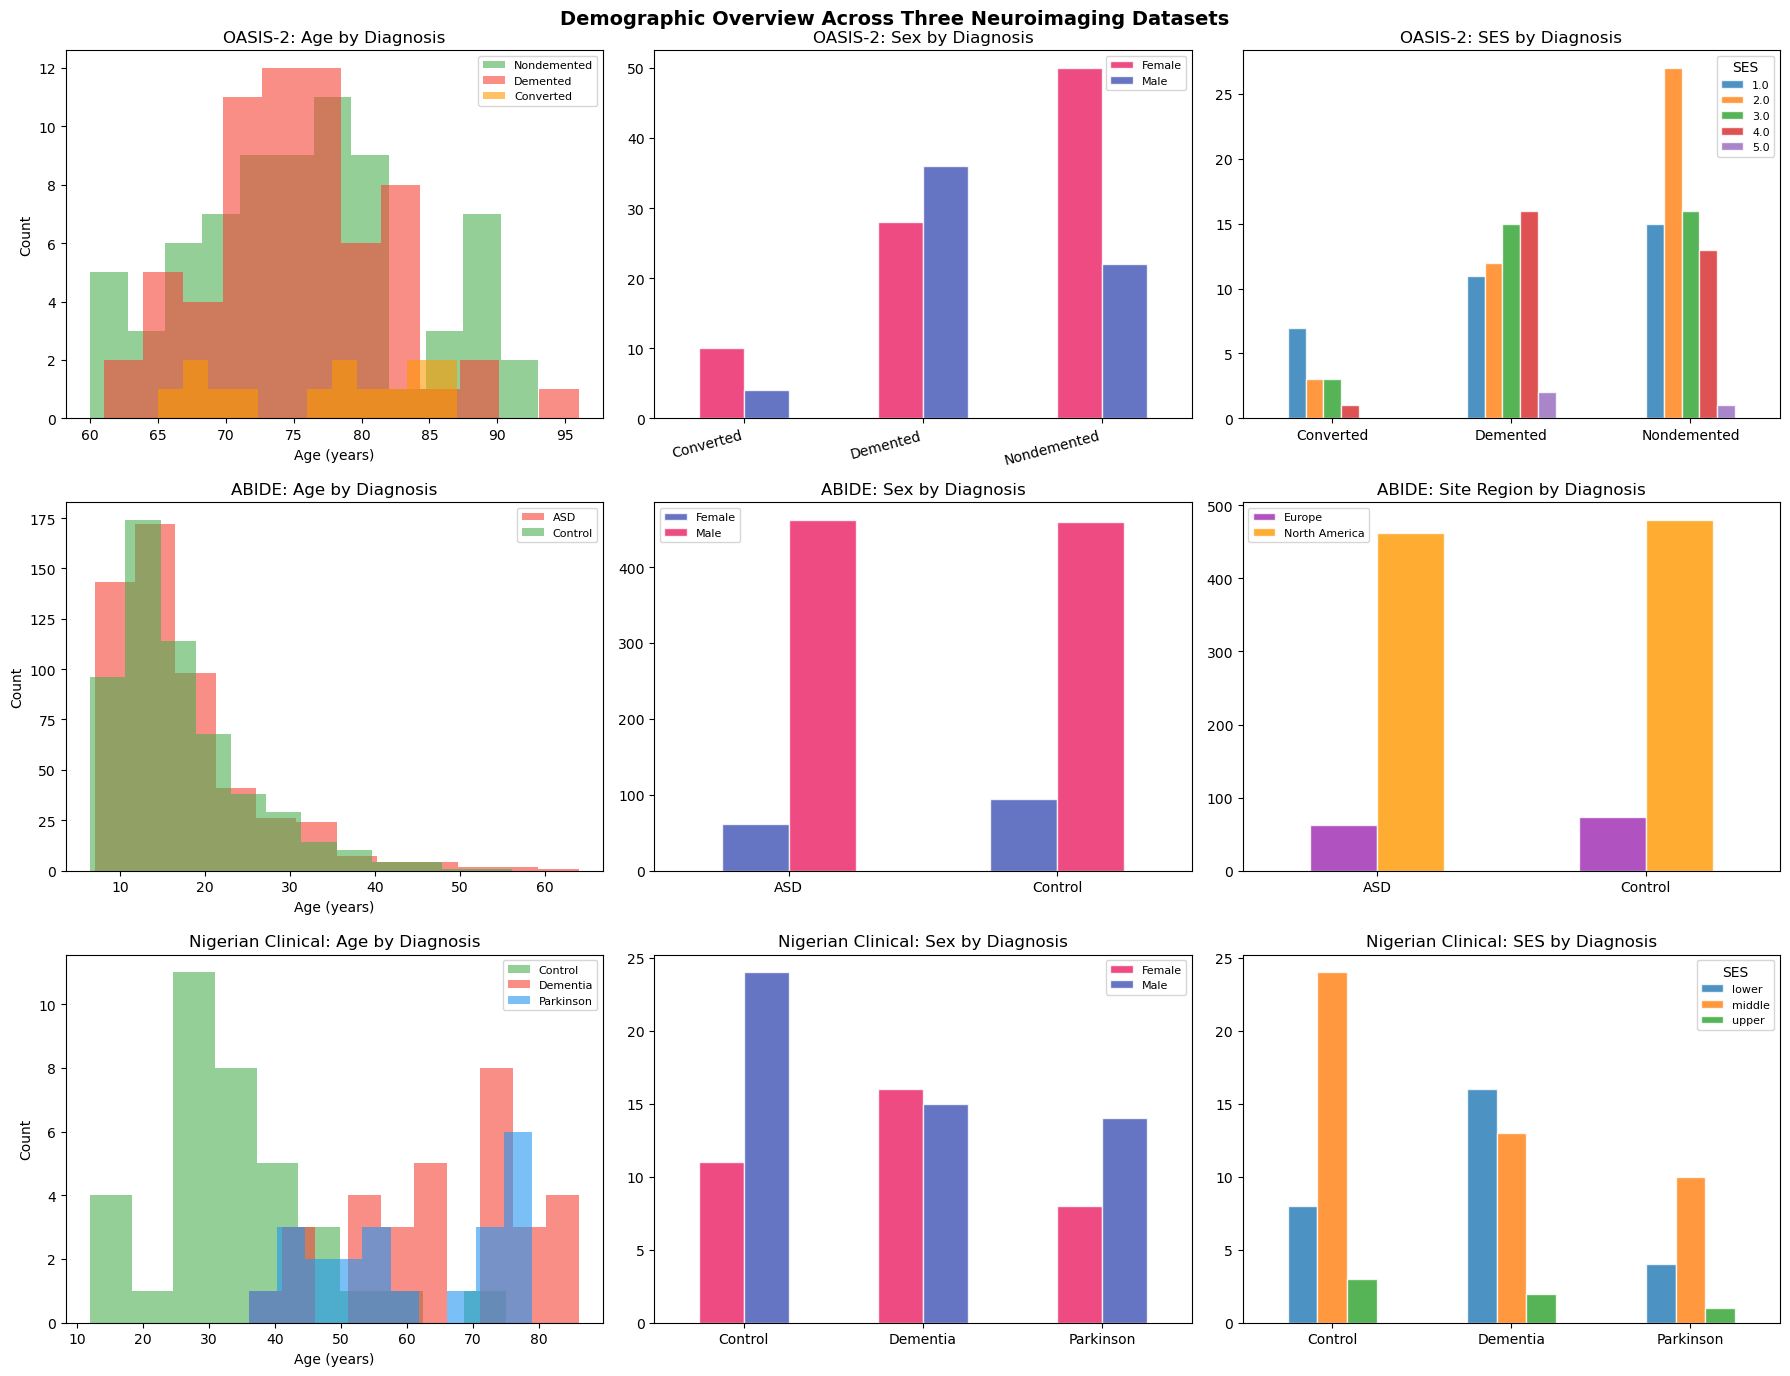

In [12]:
# ============================================================
# Block 3: Demographic Exploration
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Demographic Overview Across Three Neuroimaging Datasets',
             fontsize=14, fontweight='bold')

# ============================================================
# OASIS-2
# ============================================================

# Age distribution by diagnosis
ax = axes[0, 0]
for group, color in [('Nondemented', '#4CAF50'), ('Demented', '#F44336'), ('Converted', '#FF9800')]:
    subset = oasis_raw[oasis_raw['Visit'] == 1]
    subset = subset[subset['Group'] == group]
    ax.hist(subset['Age'], alpha=0.6, label=group, color=color, bins=12)
ax.set_title('OASIS-2: Age by Diagnosis')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

# Sex by diagnosis
ax = axes[0, 1]
oasis.groupby(['Group', 'sex']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=['#E91E63', '#3F51B5'], alpha=0.8, edgecolor='white')
ax.set_title('OASIS-2: Sex by Diagnosis')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(['Female', 'Male'], fontsize=8)

# SES by diagnosis
ax = axes[0, 2]
oasis.groupby(['Group', 'ses']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, alpha=0.8, edgecolor='white')
ax.set_title('OASIS-2: SES by Diagnosis')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='SES', fontsize=8)

# ============================================================
# ABIDE
# ============================================================

abide['diagnosis'] = abide['dx'].map({1: 'ASD', 2: 'Control'})
abide['continent'] = abide['SITE_ID'].apply(
    lambda x: 'Europe' if x in europe else 'North America')

# Age distribution by diagnosis
ax = axes[1, 0]
for group, color in [('ASD', '#F44336'), ('Control', '#4CAF50')]:
    subset = abide[abide['diagnosis'] == group]
    ax.hist(subset['age'], alpha=0.6, label=group, color=color, bins=12)
ax.set_title('ABIDE: Age by Diagnosis')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

# Sex by diagnosis
ax = axes[1, 1]
abide['sex_label'] = abide['sex'].map({1: 'Male', 2: 'Female'})
abide.groupby(['diagnosis', 'sex_label']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=['#3F51B5', '#E91E63'], alpha=0.8, edgecolor='white')
ax.set_title('ABIDE: Sex by Diagnosis')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Female', 'Male'], fontsize=8)

# Site by diagnosis
ax = axes[1, 2]
abide.groupby(['diagnosis', 'continent']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=['#9C27B0', '#FF9800'], alpha=0.8, edgecolor='white')
ax.set_title('ABIDE: Site Region by Diagnosis')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)

# ============================================================
# Nigerian Clinical
# ============================================================

# Age distribution by diagnosis
ax = axes[2, 0]
for group, color in [('Control', '#4CAF50'), ('Dementia', '#F44336'), ('Parkinson', '#2196F3')]:
    subset = nigerian[nigerian['dx'] == group]
    ax.hist(subset['age'], alpha=0.6, label=group, color=color, bins=10)
ax.set_title('Nigerian Clinical: Age by Diagnosis')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

# Sex by diagnosis
ax = axes[2, 1]
nigerian['sex_label'] = nigerian['sex'].map({'F': 'Female', 'M': 'Male'})
nigerian.groupby(['dx', 'sex_label']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=['#E91E63', '#3F51B5'], alpha=0.8, edgecolor='white')
ax.set_title('Nigerian Clinical: Sex by Diagnosis')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Female', 'Male'], fontsize=8)

# SES by diagnosis
ax = axes[2, 2]
ses_order = ['lower', 'middle', 'upper']
ses_data = nigerian.groupby(['dx', 'ses']).size().unstack(fill_value=0)
ses_data = ses_data.reindex(columns=[c for c in ses_order if c in ses_data.columns])
ses_data.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='white')
ax.set_title('Nigerian Clinical: SES by Diagnosis')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='SES', fontsize=8)

plt.subplots_adjust(hspace=0.4, wspace=0.35)
plt.tight_layout()
plt.show()

## Block 4: AIF360 Dataset Preparation

This block wraps each dataset in AIF360's `BinaryLabelDataset` format and defines privileged and unprivileged groups for the fairness audit.

### Feature sets

**OASIS-2** uses three brain-derived measures: nWBV, eTIV, and MMSE. These are the strongest neuroimaging signals in this tutorial.

**ABIDE** uses age and full scale IQ. These are not imaging-derived but are the most informative variables available in the phenotypic file without downloading raw MRI data.

**Nigerian Clinical** uses age only. No imaging-derived features are currently accessible for this dataset. This reflects real barriers to conducting a complete fairness audit on data from lower-resource settings.

### Defining privileged and unprivileged groups

There are two approaches to defining these groups and they do not always agree.

The **literature-based approach** assigns privilege based on historical patterns of access, diagnosis, and representation in research. Male is privileged in autism research because diagnostic criteria were developed from male-dominated studies. Female is privileged in dementia research because women are more likely to seek care and be included in longitudinal cohorts. Higher SES is privileged across all three datasets because access to diagnosis and research participation correlates with economic resources.

The **data-driven approach** assigns privilege based on which group has a higher favorable outcome rate in the dataset itself. In ABIDE, females actually have a higher Control rate (60.3% vs 49.8%), which contradicts the literature-based definition. In the Nigerian Clinical dataset, males have a higher Control rate (45.3% vs 31.4%), which also contradicts the literature-based definition.

This tutorial uses the literature-based approach because it grounds the fairness audit in the real-world context that produced the data. However the disagreement between the two approaches is itself informative. It suggests that outcome distributions in a dataset do not always reflect structural privilege, and that fairness audits should be interpreted alongside knowledge of how the data was collected.

| Dataset | Privileged | Unprivileged |
|---|---|---|
| OASIS-2 | Female, higher SES | Male, lower SES |
| ABIDE | Male, North America | Female, Europe |
| Nigerian Clinical | Female, higher SES | Male, lower SES |

### Ethical Checkpoint 2: Design decisions encode values

The SES threshold in OASIS-2, the site binary in ABIDE, and the privilege definitions across all three shape what the fairness metrics can and cannot detect. A different set of choices would produce different results. Document and justify these decisions in your own work.


A more conservative approach is to define privileged and unprivileged based purely on the outcome distribution in the data itself, meaning whichever group has a higher rate of favorable outcomes is privileged for that analysis.


- OASIS-2: 150 subjects, 5 features (3 brain-derived plus 2 protected attributes)

- ABIDE: 1,077 subjects, 4 features (age, IQ, plus 2 protected attributes)

- Nigerian Clinical: 88 subjects, 3 features (age plus 2 protected attributes)


#### ABIDE

Female Control rate: 60.3% vs Male Control rate: 49.8%. Females have a higher rate of the favorable outcome (being Control). This contradicts the literature-based definition where Male is privileged. By data-driven definition, Female would be privileged.

Europe Control rate: 54.1% vs North America: 51.0%. Minimal difference, site barely matters for outcome distribution.

#### Nigerian Clinical

Male Control rate: 45.3% vs Female Control rate: 31.4%. Males have a higher favorable outcome rate, which contradicts the literature-based definition where Female is privileged.

Middle/upper SES Control rate around 50% vs lower SES at 28.6%. Lower SES is genuinely disadvantaged in the data, consistent with the literature-based definition.

### References

1. Ziad Obermeyer et al. ,Dissecting racial bias in an algorithm used to manage the health of populations.Science366,447-453(2019).DOI:10.1126/science.aax2342

2. Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2021). A survey on bias and fairness in machine learning. ACM computing surveys (CSUR), 54(6), 1-35. https://dl.acm.org/doi/10.1145/3457607

3. Bellamy RKE, Dey K, Hind M, et al. AI Fairness 360: An extensible toolkit for detecting and mitigating algorithmic bias. *IBM Journal of Research and Development*. 2019;63(4/5):4:1-4:15. doi:10.1147/JRD.2019.2942287

In [13]:
# ============================================================
# Block 4: AIF360 Dataset Preparation
# ============================================================

# ============================================================
# OASIS-2
# Features: nWBV, eTIV, mmse
# Protected attributes: sex_bin, ses_bin
# ============================================================

oasis_features = ['nWBV', 'eTIV', 'mmse', 'sex_bin', 'ses_bin']
oasis_aif = oasis[oasis_features + ['label']].dropna().copy()

aif_oasis = BinaryLabelDataset(
    df=oasis_aif,
    label_names=['label'],
    protected_attribute_names=['sex_bin', 'ses_bin'],
    favorable_label=0,
    unfavorable_label=1
)

oasis_priv  = [{'sex_bin': 1, 'ses_bin': 0}]  # Female, higher SES
oasis_unpriv = [{'sex_bin': 0, 'ses_bin': 1}] # Male, lower SES

# ============================================================
# ABIDE
# Features: age, iq
# Protected attributes: sex_bin, site_bin
# ============================================================

abide_features = ['age', 'iq', 'sex_bin', 'site_bin']
abide_aif = abide[abide_features + ['label']].dropna().copy()

aif_abide = BinaryLabelDataset(
    df=abide_aif,
    label_names=['label'],
    protected_attribute_names=['sex_bin', 'site_bin'],
    favorable_label=0,
    unfavorable_label=1
)

abide_priv   = [{'sex_bin': 0, 'site_bin': 0}]  # Male, North America
abide_unpriv = [{'sex_bin': 1, 'site_bin': 1}]  # Female, Europe

# ============================================================
# Nigerian Clinical
# Features: age, sex_bin, ses_bin
# Note: no imaging features currently available in this dataset.
# Long term goal is to obtain processed imaging features
# to enable a more complete fairness audit.
# Protected attributes: sex_bin, ses_bin
# ============================================================

nigerian_features = ['age', 'sex_bin', 'ses_bin']
nigerian_aif = nigerian[nigerian_features + ['label']].dropna().copy()

aif_nigerian = BinaryLabelDataset(
    df=nigerian_aif,
    label_names=['label'],
    protected_attribute_names=['sex_bin', 'ses_bin'],
    favorable_label=0,
    unfavorable_label=1
)

nigerian_priv   = [{'sex_bin': 1, 'ses_bin': 0}]  # Female, higher SES
nigerian_unpriv = [{'sex_bin': 0, 'ses_bin': 1}]  # Male, lower SES

print("OASIS-2 AIF360 dataset:   ", aif_oasis.features.shape)
print("ABIDE AIF360 dataset:     ", aif_abide.features.shape)
print("Nigerian AIF360 dataset:  ", aif_nigerian.features.shape)

OASIS-2 AIF360 dataset:    (150, 5)
ABIDE AIF360 dataset:      (1077, 4)
Nigerian AIF360 dataset:   (88, 3)


## Block 5: Pre-Modelling Bias Detection

These metrics examine the label distribution before any model is trained. Two metrics are reported for each dataset.

#### Disparate Impact (DI)

The ratio of favorable outcome rates between unprivileged and privileged groups. A value of 1.0 means both groups receive the favorable outcome at the same rate. Below 0.8 is the threshold commonly used in US employment law to flag potential discrimination. Above 1.0 means the unprivileged group actually does better than the privileged group in the raw data.

#### Statistical Parity Difference (SPD)

The difference in favorable outcome rates between unprivileged and privileged groups. 0.0 means perfect parity. Negative means the unprivileged group has a lower favorable outcome rate. Positive means they have a higher rate.

### Results

#### OASIS-2 (DI 0.593, SPD -0.255)
The male, lower SES group is diagnosed as demented at a much higher rate than the female, higher SES group in the raw data. Before any model runs, the dataset already reflects a large gap. This could reflect real clinical differences, differences in who gets diagnosed, or both. A model trained on this data will likely inherit and potentially amplify this gap.

#### ABIDE (DI 1.162, SPD 0.080)
The female, European group has a slightly higher Control rate than the male, North American group. The gap is small and the DI is above 1.0, meaning the so-called unprivileged group is actually doing better in terms of raw label distribution. This is the dataset where our literature-based privilege definition most directly conflicts with the data. This means the bias in ABIDE is not visible at the label level. The severe sex imbalance (948 male vs 164 female) is the real story here and it does not show up in DI or SPD because those metrics only look at outcome rates, not representation.

#### Nigerian Clinical (DI 0.988, SPD -0.005)
The label distribution is nearly identical between privileged and unprivileged groups. This looks like parity but it is important not to read it as absence of bias. The Nigerian Clinical dataset has the smallest sample size, the least feature information, and no imaging data. The fairness audit here is the least complete of the three, and that incompleteness is itself a finding.

### Ethical Checkpoint 3: What these metrics miss

Pre-modelling metrics only capture bias in the label distribution. They do not capture who is missing from the dataset, whether features encode proxy variables for protected attributes, or the structural conditions that shaped data collection.

In [14]:
# ============================================================
# Block 5: Pre-Modelling Bias Detection
# ============================================================

def pre_modelling_metrics(aif_dataset, priv, unpriv, name):
    metric = BinaryLabelDatasetMetric(
        aif_dataset,
        privileged_groups=priv,
        unprivileged_groups=unpriv
    )
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Disparate Impact:              {metric.disparate_impact():.3f}")
    print(f"Statistical Parity Difference: {metric.statistical_parity_difference():.3f}")
    print(f"Base rate (privileged):        {metric.base_rate(privileged=True):.3f}")
    print(f"Base rate (unprivileged):      {metric.base_rate(privileged=False):.3f}")

pre_modelling_metrics(aif_oasis,    oasis_priv,    oasis_unpriv,    "OASIS-2")
pre_modelling_metrics(aif_abide,    abide_priv,    abide_unpriv,    "ABIDE")
pre_modelling_metrics(aif_nigerian, nigerian_priv, nigerian_unpriv, "Nigerian Clinical")


OASIS-2
Disparate Impact:              0.593
Statistical Parity Difference: -0.255
Base rate (privileged):        0.625
Base rate (unprivileged):      0.370

ABIDE
Disparate Impact:              1.162
Statistical Parity Difference: 0.080
Base rate (privileged):        0.492
Base rate (unprivileged):      0.571

Nigerian Clinical
Disparate Impact:              0.988
Statistical Parity Difference: -0.005
Base rate (privileged):        0.417
Base rate (unprivileged):      0.412


## Block 6: Classifier & Post-Modelling Fairness

A logistic regression classifier is trained on each dataset using a 70/30 train/test split. Fairness metrics are then computed on the test set predictions. Two audits are run: an intersectional audit combining both protected attributes, and a single-attribute audit on sex only.

Three metrics are reported alongside accuracy.

**Equal Opportunity Difference (EOD)** measures the difference in true positive rates between unprivileged and privileged groups. 0.0 means both groups are correctly identified at the same rate. Negative means the unprivileged group is correctly identified less often.

**Average Odds Difference (AOD)** averages the true positive rate difference and false positive rate difference. A stricter notion of fairness than EOD alone.

**Disparate Impact (DI)** at the prediction level measures whether the model assigns the favorable outcome at equal rates across groups.

### Results

**OASIS-2**
The strongest and most consistent bias signal across both audits. Intersectional DI of 0.271 means the unprivileged group receives the favorable prediction at less than a third of the rate of the privileged group. EOD of -0.714 means the model correctly identifies the unprivileged group as healthy far less often. Adding SES to sex in the intersectional audit widens the gap relative to sex alone, suggesting SES compounds the disadvantage.

**ABIDE**
The intersectional audit returns NaN across all metrics. Only 7 female European subjects exist in the entire dataset. After the train/test split, this subgroup is too small to compute reliable metrics. This is not a technical failure -- it means the most disadvantaged intersectional group is too underrepresented to audit at all. The sex-only audit shows near parity (DI 0.962, EOD 0.009), confirming that sex-based label bias is not the primary issue in ABIDE. The real problem is representation, which no fairness metric captures directly.

**Nigerian Clinical**
EOD and AOD return NaN in both audits. With 88 total subjects, the test set subgroups are too small to compute true positive rates reliably. DI is computable in both audits (0.714 intersectional, 0.838 sex only), suggesting a moderate gap, but these numbers should be interpreted with caution given the sample size.

### Ethical Checkpoint 4: What accuracy hides

ABIDE accuracy is 0.503, barely above chance, yet the model was trained on over 1,000 subjects. Nigerian Clinical accuracy is 0.815 on 88 subjects. These numbers are not comparable. Sample size, feature availability, and class balance all shape accuracy in ways that make cross-dataset comparison misleading without context.

High accuracy does not mean equitable performance. A model can perform well on aggregate while systematically failing a subgroup that is too small to show up in the overall number.

In [16]:
# ============================================================
# Block 6: Classifier & Post-Modelling Fairness
# ============================================================

def run_classifier(aif_dataset, priv, unpriv, feature_cols, name):

    # Split features and labels
    X = aif_dataset.features[:, :len(feature_cols)]
    y = aif_dataset.labels.ravel()

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Train classifier
    clf = LogisticRegression(random_state=42, max_iter=500)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Build AIF360 test datasets
    dataset_test = aif_dataset.subset(
        list(range(int(len(aif_dataset.features) * 0.7),
                   len(aif_dataset.features))))
    dataset_pred = dataset_test.copy()
    dataset_pred.labels = y_pred.reshape(-1, 1)

    # Fairness metrics
    metric = ClassificationMetric(
        dataset_test, dataset_pred,
        privileged_groups=priv,
        unprivileged_groups=unpriv
    )

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy:                      {acc:.3f}")
    print(f"Equal Opportunity Difference:  {metric.equal_opportunity_difference():.3f}")
    print(f"Average Odds Difference:       {metric.average_odds_difference():.3f}")
    print(f"Disparate Impact:              {metric.disparate_impact():.3f}")

    return clf, scaler, metric, X_train, X_test, y_train, y_test, y_pred

# ============================================================
# Intersectional audit
# ============================================================

print("INTERSECTIONAL AUDIT")
print("Protected attributes: sex + site/SES combined")

clf_oasis, scaler_oasis, metric_oasis, \
    X_train_oasis, X_test_oasis, y_train_oasis, y_test_oasis, y_pred_oasis = run_classifier(
    aif_oasis, oasis_priv, oasis_unpriv,
    ['nWBV', 'eTIV', 'mmse'], "OASIS-2")

clf_abide, scaler_abide, metric_abide, \
    X_train_abide, X_test_abide, y_train_abide, y_test_abide, y_pred_abide = run_classifier(
    aif_abide, abide_priv, abide_unpriv,
    ['age', 'iq'], "ABIDE")

clf_nigerian, scaler_nigerian, metric_nigerian, \
    X_train_nigerian, X_test_nigerian, y_train_nigerian, y_test_nigerian, y_pred_nigerian = run_classifier(
    aif_nigerian, nigerian_priv, nigerian_unpriv,
    ['age'], "Nigerian Clinical")

# ============================================================
# Single-attribute audit
# Sex only across all three datasets
# ============================================================

print("\n\nSINGLE-ATTRIBUTE AUDIT")
print("Protected attribute: sex only")

# OASIS-2 sex only
oasis_sex_features = ['nWBV', 'eTIV', 'mmse', 'sex_bin']
oasis_sex_aif = oasis[oasis_sex_features + ['label']].dropna().copy()
aif_oasis_sex = BinaryLabelDataset(
    df=oasis_sex_aif,
    label_names=['label'],
    protected_attribute_names=['sex_bin'],
    favorable_label=0,
    unfavorable_label=1
)
run_classifier(
    aif_oasis_sex,
    [{'sex_bin': 1}],
    [{'sex_bin': 0}],
    ['nWBV', 'eTIV', 'mmse'], "OASIS-2 (sex only)")

# ABIDE sex only
abide_sex_features = ['age', 'iq', 'sex_bin']
abide_sex_aif = abide[abide_sex_features + ['label']].dropna().copy()
aif_abide_sex = BinaryLabelDataset(
    df=abide_sex_aif,
    label_names=['label'],
    protected_attribute_names=['sex_bin'],
    favorable_label=0,
    unfavorable_label=1
)
run_classifier(
    aif_abide_sex,
    [{'sex_bin': 0}],
    [{'sex_bin': 1}],
    ['age', 'iq'], "ABIDE (sex only)")

# Nigerian Clinical sex only
nigerian_sex_features = ['age', 'sex_bin']
nigerian_sex_aif = nigerian[nigerian_sex_features + ['label']].dropna().copy()
aif_nigerian_sex = BinaryLabelDataset(
    df=nigerian_sex_aif,
    label_names=['label'],
    protected_attribute_names=['sex_bin'],
    favorable_label=0,
    unfavorable_label=1
)
run_classifier(
    aif_nigerian_sex,
    [{'sex_bin': 1}],
    [{'sex_bin': 0}],
    ['age'], "Nigerian Clinical (sex only)")

INTERSECTIONAL AUDIT
Protected attributes: sex + site/SES combined

OASIS-2
Accuracy:                      0.689
Equal Opportunity Difference:  -0.714
Average Odds Difference:       -0.507
Disparate Impact:              0.271

ABIDE
Accuracy:                      0.503
Equal Opportunity Difference:  nan
Average Odds Difference:       nan
Disparate Impact:              nan

Nigerian Clinical
Accuracy:                      0.815
Equal Opportunity Difference:  nan
Average Odds Difference:       nan
Disparate Impact:              0.714


SINGLE-ATTRIBUTE AUDIT
Protected attribute: sex only

OASIS-2 (sex only)
Accuracy:                      0.689
Equal Opportunity Difference:  -0.625
Average Odds Difference:       -0.312
Disparate Impact:              0.732

ABIDE (sex only)
Accuracy:                      0.503
Equal Opportunity Difference:  0.009
Average Odds Difference:       -0.044
Disparate Impact:              0.962

Nigerian Clinical (sex only)
Accuracy:                      0.815
Equ

(LogisticRegression(max_iter=500, random_state=42),
 StandardScaler(),
 array([[-1.38974161],
        [-0.88871184],
        [-0.83860886],
        [-0.93881481],
        [-1.1893297 ],
        [ 0.11334772],
        [ 0.81478941],
        [ 0.1634507 ],
        [ 1.31581919],
        [-0.53799099],
        [ 0.91499537],
        [-1.94087437],
        [ 1.11540728],
        [ 1.0653043 ],
        [-1.79056544],
        [-0.63819695],
        [-1.69035948],
        [-0.63819695],
        [ 1.01520132],
        [ 0.56427452],
        [ 1.36592217],
        [ 1.0653043 ],
        [ 0.31375963],
        [-0.23737312],
        [ 1.01520132],
        [ 1.61643706],
        [ 0.1634507 ],
        [ 1.01520132],
        [-0.03696121],
        [-0.58809397],
        [-1.1893297 ],
        [-0.68829993],
        [ 0.96509834],
        [-0.93881481],
        [ 0.01314176],
        [ 0.06324474],
        [ 0.56427452],
        [ 0.91499537],
        [ 0.01314176],
        [ 1.21561323],
        [

In [18]:
# ============================================================
# Block 7: Mitigation & The Accuracy-Fairness Tradeoff
# ============================================================

def run_reweighing(aif_dataset, priv, unpriv, feature_cols, name):

    # Apply reweighing
    RW = Reweighing(
        privileged_groups=priv,
        unprivileged_groups=unpriv
    )
    aif_reweighed = RW.fit_transform(aif_dataset)

    # Split features, labels, and weights
    X = aif_reweighed.features[:, :len(feature_cols)]
    y = aif_reweighed.labels.ravel()
    w = aif_reweighed.instance_weights.ravel()

    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, w, test_size=0.3, random_state=42, stratify=y)

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Train classifier with sample weights
    clf = LogisticRegression(random_state=42, max_iter=500)
    clf.fit(X_train, y_train, sample_weight=w_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Build AIF360 test datasets
    dataset_test = aif_dataset.subset(
        list(range(int(len(aif_dataset.features) * 0.7),
                   len(aif_dataset.features))))
    dataset_pred = dataset_test.copy()
    dataset_pred.labels = y_pred.reshape(-1, 1)

    # Fairness metrics
    metric = ClassificationMetric(
        dataset_test, dataset_pred,
        privileged_groups=priv,
        unprivileged_groups=unpriv
    )

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy:                      {acc:.3f}")
    print(f"Equal Opportunity Difference:  {metric.equal_opportunity_difference():.3f}")
    print(f"Average Odds Difference:       {metric.average_odds_difference():.3f}")
    print(f"Disparate Impact:              {metric.disparate_impact():.3f}")

    return metric

# ============================================================
# Intersectional reweighing
# ============================================================

print("INTERSECTIONAL REWEIGHING")

metric_oasis_rw = run_reweighing(
    aif_oasis, oasis_priv, oasis_unpriv,
    ['nWBV', 'eTIV', 'mmse'], "OASIS-2")

metric_abide_rw = run_reweighing(
    aif_abide, abide_priv, abide_unpriv,
    ['age', 'iq'], "ABIDE")

metric_nigerian_rw = run_reweighing(
    aif_nigerian, nigerian_priv, nigerian_unpriv,
    ['age'], "Nigerian Clinical")

# ============================================================
# Sex-only reweighing
# ============================================================

print("\n\nSEX-ONLY REWEIGHING")

run_reweighing(
    aif_oasis_sex,
    [{'sex_bin': 1}],
    [{'sex_bin': 0}],
    ['nWBV', 'eTIV', 'mmse'], "OASIS-2 (sex only)")

run_reweighing(
    aif_abide_sex,
    [{'sex_bin': 0}],
    [{'sex_bin': 1}],
    ['age', 'iq'], "ABIDE (sex only)")

run_reweighing(
    aif_nigerian_sex,
    [{'sex_bin': 1}],
    [{'sex_bin': 0}],
    ['age'], "Nigerian Clinical (sex only)")

INTERSECTIONAL REWEIGHING

OASIS-2
Accuracy:                      0.667
Equal Opportunity Difference:  -0.643
Average Odds Difference:       -0.471
Disparate Impact:              0.292

ABIDE
Accuracy:                      0.500
Equal Opportunity Difference:  nan
Average Odds Difference:       nan
Disparate Impact:              nan

Nigerian Clinical
Accuracy:                      0.815
Equal Opportunity Difference:  nan
Average Odds Difference:       nan
Disparate Impact:              0.714


SEX-ONLY REWEIGHING

OASIS-2 (sex only)
Accuracy:                      0.644
Equal Opportunity Difference:  -0.625
Average Odds Difference:       -0.396
Disparate Impact:              0.607

ABIDE (sex only)
Accuracy:                      0.500
Equal Opportunity Difference:  0.009
Average Odds Difference:       -0.016
Disparate Impact:              0.985

Nigerian Clinical (sex only)
Accuracy:                      0.815
Equal Opportunity Difference:  nan
Average Odds Difference:       nan
Dispara

### Ethical Checkpoint 4: Is mitigation enough?

Reweighing improved fairness metrics — but consider:

1. **The age confound is untouched.** Controls are still ~30 years younger. Reweighing by sex does not fix a structural data problem.

2. **The scanner quality gap is untouched.** 0.3T participants still have lower quality images. No algorithmic fix replaces better infrastructure.

3. **The sample is still n=88.** Improved metrics on a test set of ~26 participants are not reliable.

**The most meaningful interventions are upstream:**
- Longitudinal data collection with age-matched controls
- Higher-field MRI infrastructure investment in Africa  
- Community-driven data governance frameworks
- More datasets like this one

> *Fairness toolkits are diagnostic tools, not solutions.*

---

## Resources
- OASIS Brains: https://sites.wustl.edu/oasisbrains/
- Teaching and Research in Natural Sciences for Development (TReND) in Africa: https://trendinafrica.org/
- IBM AI Fairness 360 documentation: https://aif360.readthedocs.io/
- OpenNeuro: https://openneuro.org/
- African Brain Data Network: https://africanbraindata.net/

## Generative AI Use Statement

Portions of the code in this notebook were developed with assistance from 
Claude (Anthropic), an AI assistant, as part of an iterative development 
process. All code was reviewed, tested, and validated by the author. 
AI assistance was used for code generation and debugging; all analytical 
decisions, ethical framing, and interpretations are the author's own.